In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset
data = pd.read_csv('train.csv')

# Select features
X = data[['Pclass', 'Age', 'Fare']]

# Fill missing Age values
X['Age'] = X['Age'].fillna(X['Age'].mean())

# Target variable
y = data['Survived']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# New passenger prediction
new_passenger = [[1, 30, 80]]
prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")


Accuracy: 0.7374301675977654
[[93 12]
 [35 39]]
Passenger Survived


/tmp/ipykernel_290/1337856031.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'] = X['Age'].fillna(X['Age'].mean())
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Accuracy: 0.7374301675977654
Confusion Matrix:
[[93 12]
 [35 39]]
Passenger Survived


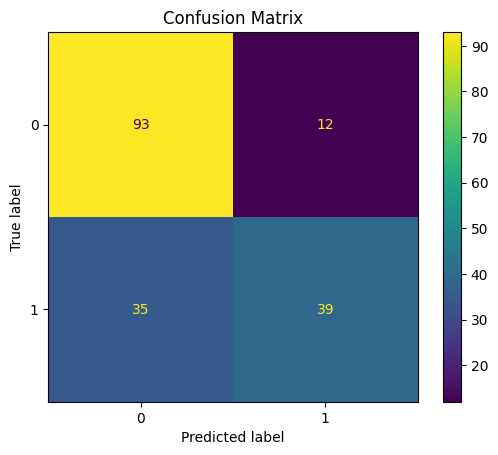

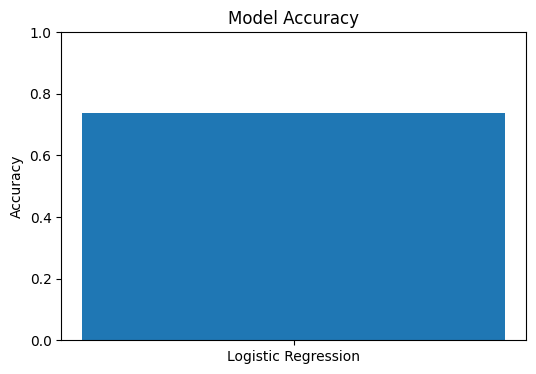

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Load dataset
data = pd.read_csv('train.csv')

# Features and Target
X = data[['Pclass', 'Age', 'Fare']].copy()
X.loc[:, 'Age'] = X['Age'].fillna(X['Age'].mean())

y = data['Survived']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# New passenger prediction
new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Age': [30],
    'Fare': [80]
})

prediction = model.predict(new_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

# -----------------------------
# Graphical Representation
# -----------------------------

# Confusion Matrix Graph
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Accuracy Bar Chart
plt.figure(figsize=(6,4))
plt.bar(['Logistic Regression'], [accuracy])
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.ylim(0, 1)
plt.show()